In [1]:
import torch
import torch.nn as nn
import torchaudio
from transformers import Wav2Vec2CTCTokenizer

/home/ishan/anaconda3/envs/josh.ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
os.chdir('../data/')
from dataset import PositionalEncoding

In [3]:
os.chdir('../model/')

In [4]:
tokenizer = Wav2Vec2CTCTokenizer.from_pretrained('../data/my_tokenizer/')

In [5]:
class S2T(nn.Module):
    def __init__(self,n_mels=80,vocab_size=31):
        super().__init__()
        self.pos_encoding = PositionalEncoding(d_model=600)
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=n_mels, out_channels=400, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Conv1d(in_channels=400, out_channels=600, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(p=0.3),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=600,
            nhead=8,
            dim_feedforward=2048,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.fc = nn.Linear(600,vocab_size)
    def forward(self,x):
        x = x.float()
        x = x.permute(0,2,1)
        x = self.cnn(x)
        x = x.permute(0,2,1)
        x = self.pos_encoding(x)
        x = self.transformer(x)
        x = self.fc(x)
        return x

In [6]:

model = S2T(n_mels=80,vocab_size=33)
model.load_state_dict(torch.load('../data/best_model.pt',weights_only=True))
# model.eval()
# model.to('cpu')

<All keys matched successfully>

In [7]:
total_params = sum(p.numel() for p in model.parameters())

In [8]:
total_params

16457025

In [9]:
audio, sr = torchaudio.load('output.flac')

audio = audio.mean(dim=0, keepdim=True)

if sr != 16000:
    audio = torchaudio.transforms.Resample(sr, 16000)(audio)
sr = 16000

mel_transform = nn.Sequential(
    torchaudio.transforms.MelSpectrogram(
        sample_rate=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=80
    ),
    torchaudio.transforms.AmplitudeToDB()
)

mel_audio = mel_transform(audio)   # (1, 80, time)
print(mel_audio.shape)

logits = None
with torch.no_grad():
    mel_audio.to('cpu')
    logit = model(mel_audio)

torch.Size([1, 80, 70])


RuntimeError: Given groups=1, weight of size [400, 80, 3], expected input[1, 70, 80] to have 80 channels, but got 70 channels instead

In [ ]:
pred_ids = torch.argmax(logit,dim=-1)[0].tolist()

In [36]:
text = tokenizer.decode(pred_ids)

In [37]:
text

''

In [17]:
import pickle
import os

In [18]:
os.chdir('../data/')

In [19]:
os.listdir()

['LibriSpeech',
 'best_model.pt',
 'processed_data',
 'vocab.json',
 '.DS_Store',
 '__pycache__',
 'output.txt',
 'dataset.py',
 'process_data.ipynb',
 'outputs.pkl',
 'my_tokenizer']

In [20]:
with open('outputs.pkl','rb') as f:
    loss_arr = pickle.load(f)


In [21]:
import matplotlib.pyplot as plt

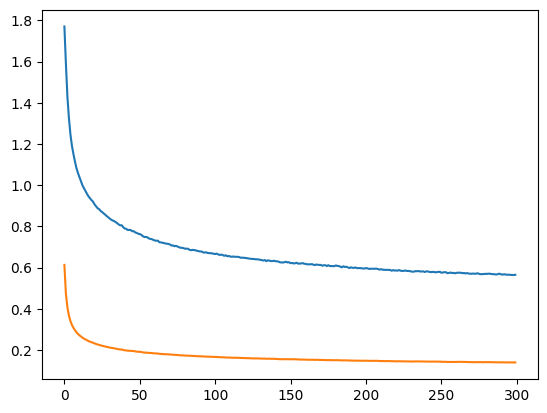

In [23]:
# plt.plot(loss_arr['loss'])
plt.plot(loss_arr['wer'])
plt.plot(loss_arr['cer'])
# plt.show()

In [27]:
min_wer = min(loss_arr['wer'])
min_cer = min(loss_arr['cer'])


In [28]:
print(f"minimum wer: {min_wer}")
print(f"minimum cer: {min_cer}")

minimum wer: 0.5642059536439655
minimum cer: 0.13954367455700836
